# Grundgerüst Leistungsausweis
Dieses Notebook soll euch als Grundgerüst für euren Leistungsnachweis dienen. Es soll euch eine Idee/ Hilfestellung bieten, wie man einen neuen Datensatz, basierend auf einer Fragestellung, strukturiert analysieren und interpretieren kann. Wie besagt, dient das Notebook als Hilfestellung, ist jedoch keinenfalls vollständig ausgeschöpft. In diesem Sinne dürft ihr auch gerne Sachen miteinbeziehen, welche hier nicht genannt werden. 

-> Bitte schreibt die Antwort zu den jeweiligen Punkten an oberster Stelle unterhalb der Titel (so wie dies auch im Leistungsnachweisbeispiel gemacht wurde).


## Struktur
1. Fragestellung(en) und Datenbeschaffung
2. Daten laden
3. Daten vorbereiten
4. Statistik der Rohdaten (Generell im Longformat)
5. Analyse der Daten

**Wichtig:** Alle graphischen Darstellungen sollten mindestens *Titel, Ticks- und Achsenbeschriftung* beinhalten (Siehe plots im Leistungsnachweisbeispiel)

---

## 1. Fragestellung(en) und Datenbeschaffung
### 1.1 Titel: 
- Fertilitiy-rate
### 1.2 Fragestellung:
- Wie haben sich die Fruchtbarkeitsraten auf den sechs Kontinenten (Europa, Nord- und Südamerika, Asien, Afrika, Australien) seit 1950 entwickelt?
- Unterscheidet sich die Entwicklung der Fruchtbarkeitsraten zwischen Afrika und Asien seit 1970, und welcher der beiden Kontinenten zeigt stärkere Veränderungen?
### 1.3 Datenquelle(n):
- https://ourworldindata.org/grapher/children-born-per-woman?country=OWID_WRL~USA~GBR~RUS~DEU~JPN~IND~CHE




### 1.4 Daten beschaffen und laden

In [17]:
# lade deine Bibliotheken -> Pandas, Seaborn, Matplotlib sind die wichtigsten für diese Aufgaben

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [18]:
# lade hier deine Daten

data = pd.read_csv('children-born-per-woman.csv')

data.head()

,Entity,Code,Year,"Fertility rate (period), historical"
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


## 2. Daten vorbereiten 
- Welches Format hat mein Datensatz bzw. wie sind meine Kolumnen strukturiert?
- Welches Format kann ich für welche Teilschritte verwenden (wann soll ich pivot bzw. wide format verwenden)?
- Welche Datentypen kommen in meinem Datensatz vor?

In [19]:
print(data.dtypes)

df_pivot = data.pivot(index='Entity', columns='Year', values='Fertility rate (period), historical')
df_pivot.head()

Entity                                  object
Code                                    object
Year                                     int64
Fertility rate (period), historical    float64
dtype: object


Year,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.770,5.652,5.542,5.433,5.327,5.238,5.145,5.039,4.932,4.840
Africa (UN),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.686,4.625,4.545,4.482,4.391,4.312,4.242,4.179,4.125,4.072
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.721,1.631,1.555,1.486,1.415,1.395,1.371,1.365,1.355,1.348
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.084,3.091,3.091,3.090,3.019,2.997,2.940,2.870,2.817,2.766
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.852,2.780,2.699,2.598,2.494,2.404,2.360,2.327,2.305,2.286


## 3. Statistik der Rohdaten (Analyse im Long-Format)
Folgende Aussagen können über die einzelnen Spalten getroffen werden:

- Die Spalte 'Entity' enthält 255 verschiedene Gebiete.
- Die Spalte 'Code' enthält die Länderodes von 238 Gebieten.
- Die Spalte 'Year' enthält 133 Jahreszahlen zwischen 1891 und 2023. Ab 1950 sind die Daten aller Gebiete vorhanden.
- Die Spalte 'Fertility rate (period), historical' enthält 18958 Datenpunkte zur Fertilitätsrate in den jeweiligen Gebieten. Die streut zwischen 0.662 und 8.864 bei einem Durchschnitt von 3.947.





In [20]:
data.dtypes

Entity                                  object
Code                                    object
Year                                     int64
Fertility rate (period), historical    float64
dtype: object

### 3.1 Analyse Gebiete

In [21]:
data['Entity'].value_counts()

Entity
Sweden               133
Denmark              108
Canada               103
Spain                102
Switzerland           92
                    ... 
Western Sahara        74
Zimbabwe              74
Yemen                 74
England and Wales     12
Scotland               5
Name: count, Length: 255, dtype: int64

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Entity', ylabel='Anzahl Datenpunkte'>

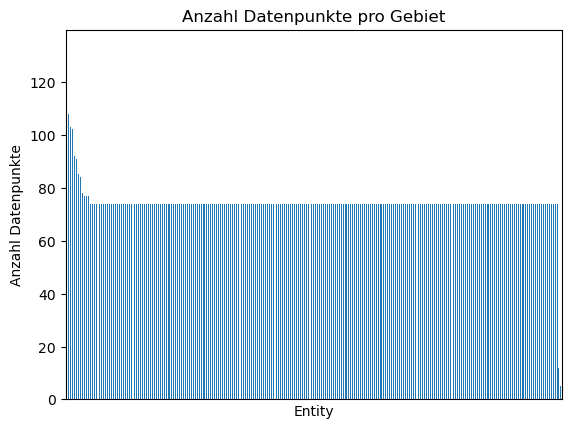

In [22]:
data['Entity'].value_counts().plot(kind='bar', 
                                 xticks=[],     # disable labels on x-axis
                                 ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.2 Analyse Codes

In [34]:
data['Code'].value_counts()

Code
SWE         133
DNK         108
CAN         103
ESP         102
CHE          92
           ... 
ESH          74
OWID_WRL     74
YEM          74
ZMB          74
ZWE          74
Name: count, Length: 238, dtype: int64

### 3.3 Analyse Jahr


In [38]:
data['Year'].value_counts()

Year
1950    253
1951    253
1952    253
1953    253
1954    253
       ... 
1911      1
1912      1
1913      1
1914      1
1915      1
Name: count, Length: 133, dtype: int64

In [39]:
data['Year'].min()

1891

In [40]:

data['Year'].max()

2023

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Year', ylabel='Anzahl Datenpunkte'>

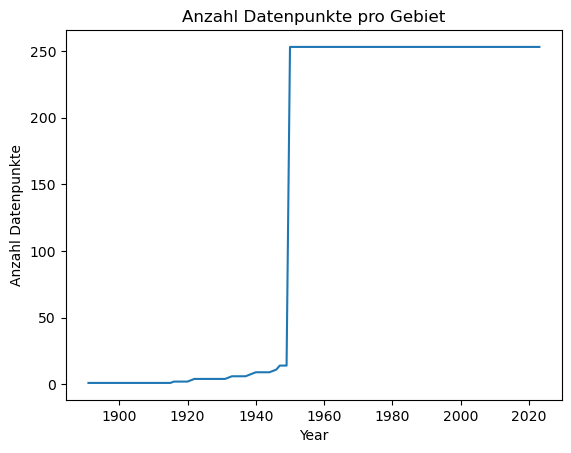

In [24]:
data['Year'].value_counts().sort_index().plot(kind='line',ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.3 Analyse Fertilitätsrate

In [35]:
data.describe()

,Year,"Fertility rate (period), historical"
count,18958.000000,18958.000000
mean,1985.846661,3.947225
std,22.064795,1.998850
min,1891.000000,0.662000
25%,1967.000000,2.134000
50%,1986.000000,3.481000
75%,2005.000000,5.876000
max,2023.000000,8.864000


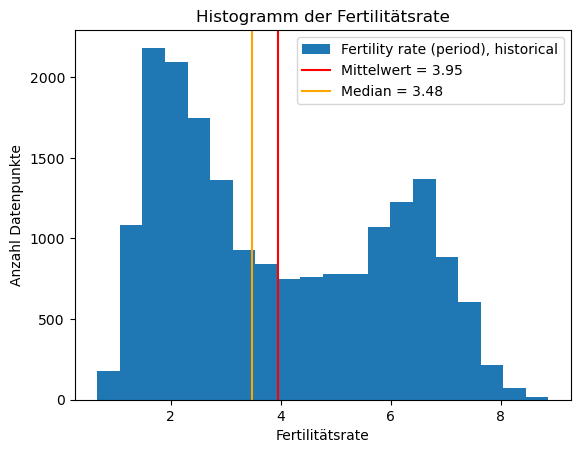

In [36]:
g = data['Fertility rate (period), historical'].plot(kind='hist', bins=20, title='Histogramm der Fertilitätsrate', 
                           xlabel='Fertilitätsrate', ylabel='Anzahl Datenpunkte')
mean = data['Fertility rate (period), historical'].mean()
g.axvline(x=data['Fertility rate (period), historical'].mean(), color='red',label=f'Mittelwert = {mean:.2f}')  # rote Linie bei Mittelwert

median = data['Fertility rate (period), historical'].median()
g.axvline(x=data['Fertility rate (period), historical'].median(), color='orange',label=  f'Median = {median:.2f}')  # orange Linie bei Median

g.legend()

## 4. Analyse 

### Vorgehen
- Spezifische Untersuchung der Fragestellung (Berechnungen)
- Visualisieren der Resultate: Verwendet Achsenbeschriftung und überlegt euch, welche Art von Darstellung sinnvoll ist (Kuchen-, Säulen, Liniendiagramm; 2 y-Achsen?)
- Beschreiben der Beobachtungen
- Interpretation der Resultate (Hypothesen zu den Resultaten)
- Untermauern der Interpretation mittels Hinweise zur Literatur (Mögliche Zusammenhänge aufzeigen).



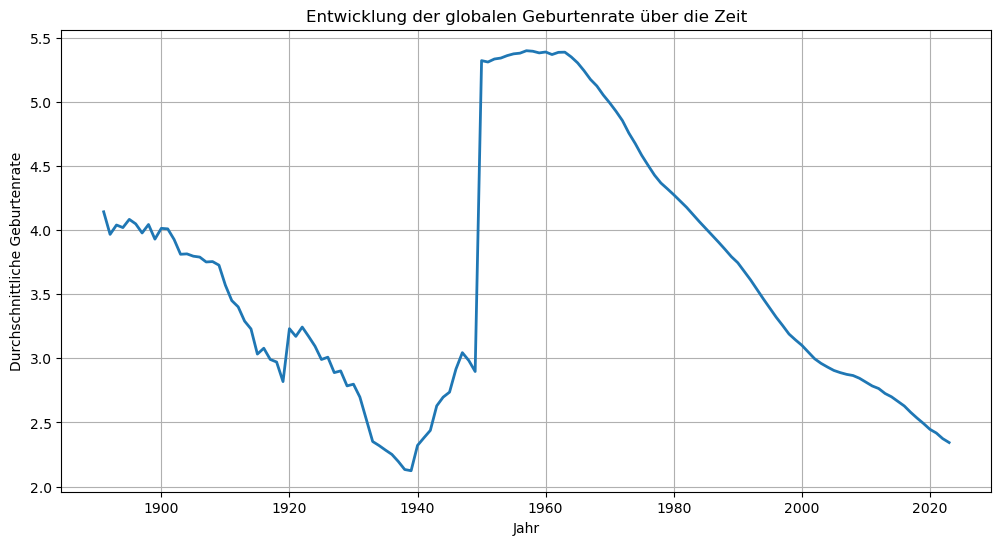

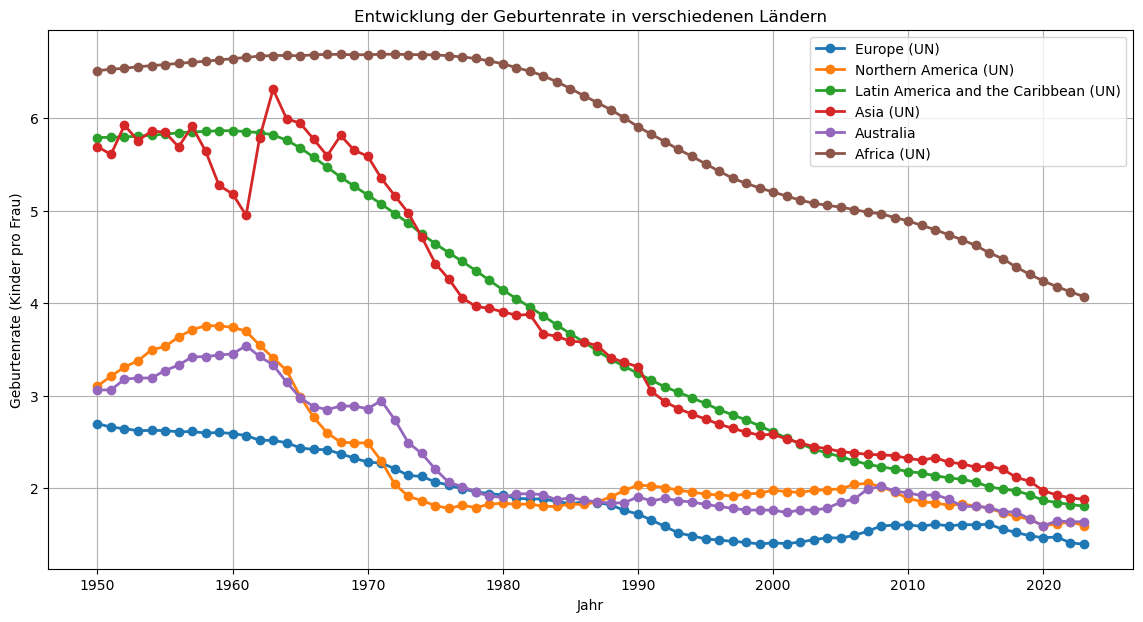

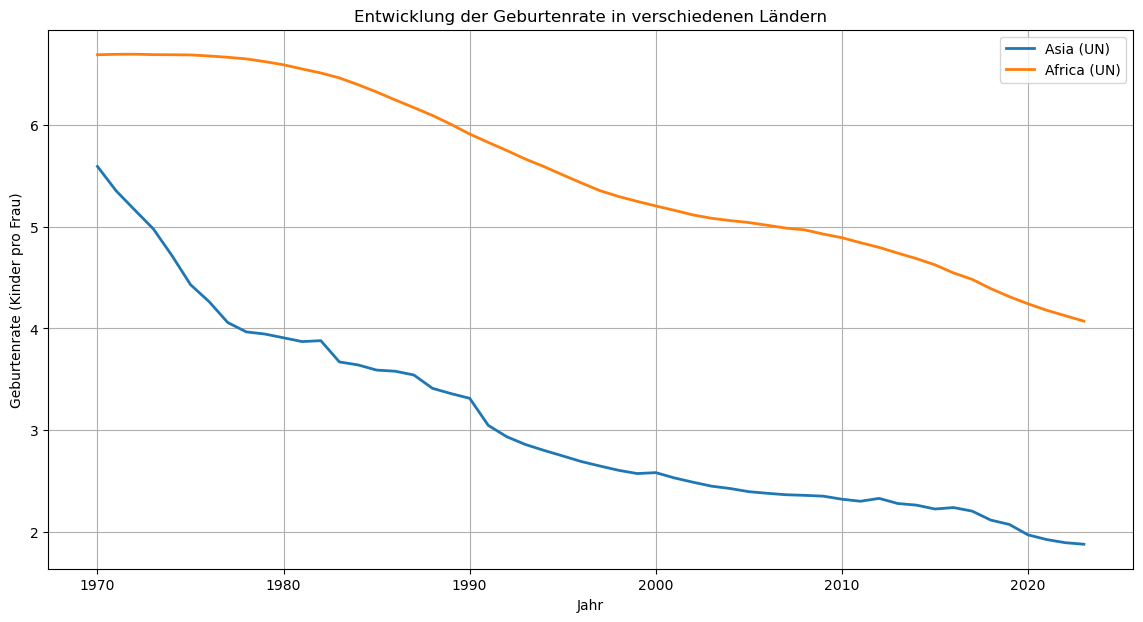

C:\Users\winze\AppData\Local\Temp\ipykernel_12220\2903896092.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_data['Diff'] = country_data['Fertility rate (period), historical'].diff()
C:\Users\winze\AppData\Local\Temp\ipykernel_12220\2903896092.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_data['Diff'] = country_data['Fertility rate (period), historical'].diff()


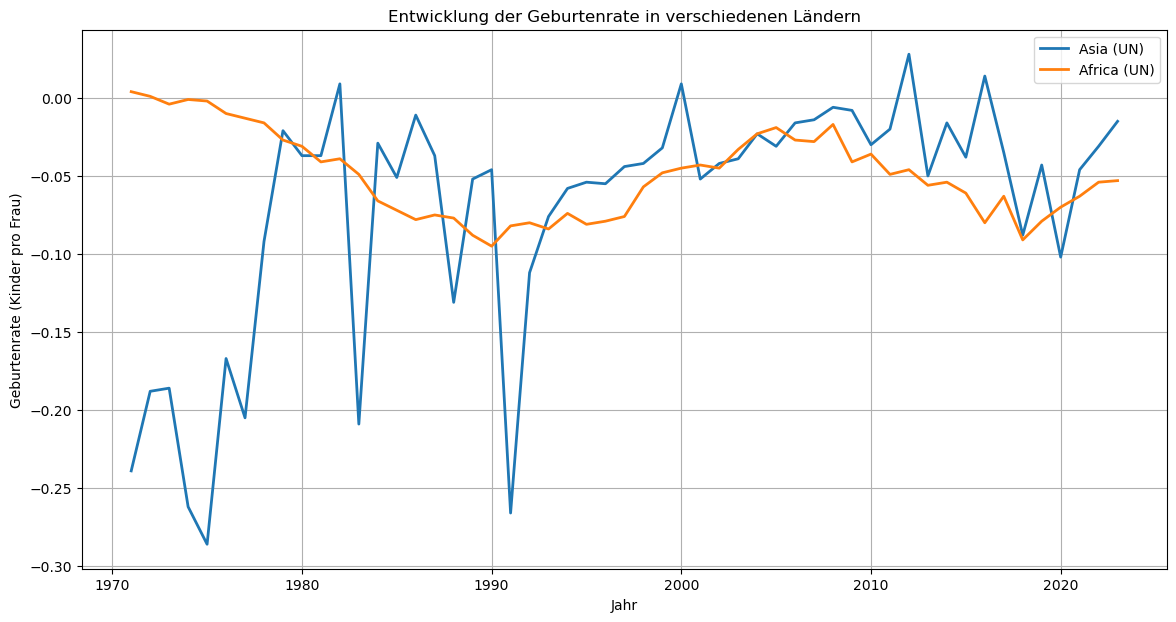

In [33]:
# Beschreibende Statistik
data.describe()

# Wie viele Länder sind im Datensatz?
data['Entity'].nunique()

# Fehlende Werte prüfen
data.isnull().sum()

# VISUALISIERUNGEN:

# Zeitliche Entwicklung - Globaler Durchschnitt
global_avg = data.groupby('Year')['Fertility rate (period), historical'].mean()

plt.figure(figsize=(12,6))
plt.plot(global_avg.index, global_avg.values, linewidth=2)
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche Geburtenrate')
plt.title('Entwicklung der globalen Geburtenrate über die Zeit')
plt.grid(True)
plt.show()

# Vergleich ausgewählter Länder über Zeit
countries = ['Europe (UN)', 'Northern America (UN)', 'Latin America and the Caribbean (UN)', 'Asia (UN)', 'Australia', 'Africa (UN)']

plt.figure(figsize=(14,7))
for country in countries:
    country_data = data[data['Entity'] == country]
    plt.plot(country_data['Year'], 
             country_data['Fertility rate (period), historical'], 
             marker='o', label=country, linewidth=2)

plt.xlabel('Jahr')
plt.ylabel('Geburtenrate (Kinder pro Frau)')
plt.title('Entwicklung der Geburtenrate in verschiedenen Ländern')
plt.legend()
plt.grid(True)
plt.show()

# Vergleich Asien und Afrika

countries = ['Asia (UN)', 'Africa (UN)']

plt.figure(figsize=(14,7))
for country in countries:
    country_data = data[(data['Entity'] == country) & (data['Year']>=1970)]
    plt.plot(country_data['Year'], 
             country_data['Fertility rate (period), historical'], label=country, linewidth=2)


plt.xlabel('Jahr')
plt.ylabel('Geburtenrate (Kinder pro Frau)')
plt.title('Entwicklung der Geburtenrate in verschiedenen Ländern')
plt.legend()
plt.grid(True)
plt.show()

# Vergleich Ableitung

countries = ['Asia (UN)', 'Africa (UN)']

plt.figure(figsize=(14,7))
for country in countries:
    country_data = data[(data['Entity'] == country) & (data['Year']>=1970)]
    country_data['Diff'] = country_data['Fertility rate (period), historical'].diff()

    plt.plot(country_data['Year'], 
             country_data['Diff'], label=country, linewidth=2)


plt.xlabel('Jahr')
plt.ylabel('Geburtenrate (Kinder pro Frau)')
plt.title('Entwicklung der Geburtenrate in verschiedenen Ländern')
plt.legend()
plt.grid(True)
plt.show()
